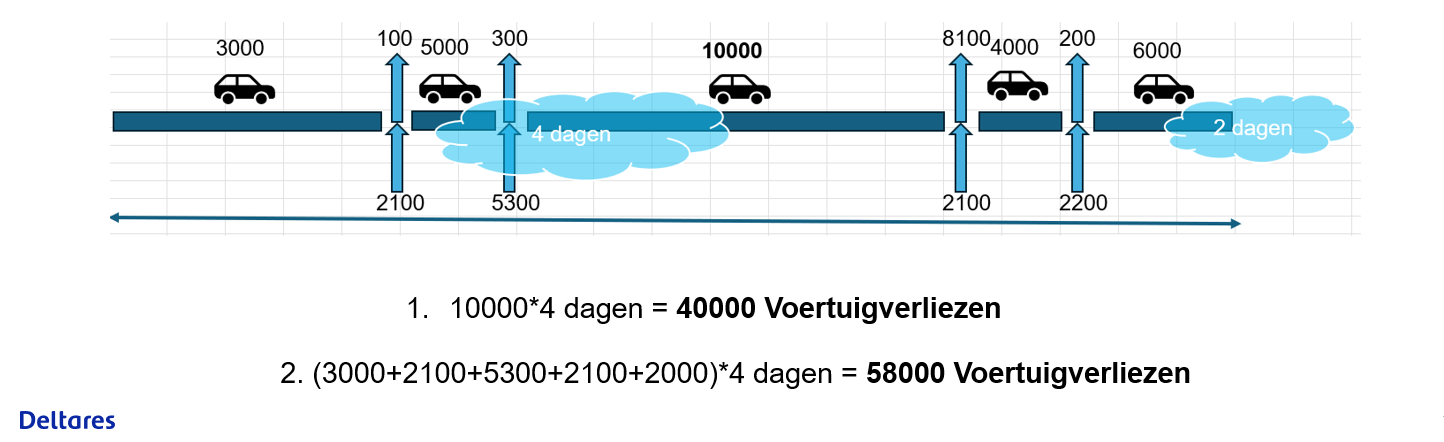

In [1]:
from pathlib import Path
import geopandas as gpd

In [2]:
region_list = ["ARK-NZK","Vallei en Veluwe",
               "Achterhoek", "Brabantse Delta","Friesland",
               "Groningen en NO-Drenthe","Limburg",
               "Noord-Brabant Oost","Noord-Westelijke Delta",
               "Rivierenland","Scheldestromen","Zuiderzeeland",
               "Overijsselse Vecht"
               ]

In [16]:
#Linking traffic data road segments
import pandas as pd
root_dir = Path(r"P:\bovenregionale-stresstest-hwn\Analysis\Traffic_Analysis_Data")
root_dir.mkdir(parents=True, exist_ok=True)
data = Path(r"P:\bovenregionale-stresstest-hwn\Data\Traffic_data\INWEVA_2024 (1)")
traffic_geometry_path=data.joinpath("INWEVA_2024_netwerk\INWEVA_2024_netwerk.shp") 
werkdag_traffic_csv_path = data.joinpath("inweva_werkdag_2024DEC.csv")
traffic_geometry= gpd.read_file(traffic_geometry_path, driver='SHP') 
traffic= pd.read_csv(werkdag_traffic_csv_path, sep=';') 

traffic_subset = traffic[['VBN_ID', 'AL_E_WR', 'VRPC_E_WR', "L1_E_WR","L2_E_WR","L3_E_WR"]]
traffic_subset['VBN_ID'] = traffic_subset['VBN_ID'].astype(str)
result = traffic_geometry.merge(traffic_subset, left_on='vbn_id', right_on='VBN_ID', how='left')
print(f"Original traffic_geometry rows: {len(traffic_geometry)}")
print(f"Result rows: {len(result)}")
print(result.columns.tolist())

# Save the result as a geopackage
# Rename the VBN_ID column to avoid conflicts
result_renamed = result.rename(columns={'VBN_ID': 'traffic_vbn_id'})

output_path = root_dir.joinpath("traffic_werkdag_2024DEC_etmaalintensiteiten.gpkg")
if output_path.exists():  # overwrite existing file
    output_path.unlink()
result_renamed.to_file(output_path, driver='GPKG')
print(f"Saved merged data to: {output_path}")
#print(f"Saved merged data to: {output_path}")

result_renamed = result.drop(columns=['VBN_ID'])# Rename the VBN_ID column to avoid conflicts
result_exploded = result_renamed.copy()# Split nwb_ids and create duplicate rows for each value
result_exploded['nwb_ids'] = result_exploded['nwb_ids'].str.split(', ')# Split the nwb_ids column by comma and expand into separate rows
result_exploded = result_exploded.explode('nwb_ids')
result_exploded = result_exploded.reset_index(drop=True)# Reset index after exploding
result_exploded['individual_nwb_id'] = result_exploded['nwb_ids']# Create a new column with individual nwb_id values
#print(f"Original rows: {len(result_renamed)}")
#print(f"Exploded rows: {len(result_exploded)}")


### check here!!!
# Select only the required columns from traffic and create a proper copy
#AL_E_WR = Totale INWEVA intensiteit over periode 'dag' 
#VRPC_E_WR = Vrachtpercentage dag werkdag, Freight percentage day working day
traffic_subset_ver01 = result_exploded[['individual_nwb_id', 'AL_E_WR', 'VRPC_E_WR', "L1_E_WR","L2_E_WR","L3_E_WR"]].copy() 
# Convert both columns to string to ensure they match
traffic_subset_ver01['individual_nwb_id'] = traffic_subset_ver01['individual_nwb_id'].astype(str)

C:\Users\meije_le\AppData\Local\Temp\ipykernel_31052\4025688485.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  traffic_subset['VBN_ID'] = traffic_subset['VBN_ID'].astype(str)


Original traffic_geometry rows: 9049
Result rows: 9049
['vbn_id', 'vbn_oms_tx', 'vbn_oms_bp', 'vbn_lengte', 'regio_cntr', 'regio_alt', 'nwb_ids', 'wegnrhmp_b', 'wegnrhmp_e', 'bpszijde_b', 'bpszijde_e', 'hectoltr_b', 'hectoltr_e', 'bnsubsrt_b', 'bnsubsrt_e', 'km_b', 'km_e', 'hm_midden', 'vbn_id_tgn', 'vias_baan', 'geometry', 'VBN_ID', 'AL_E_WR', 'VRPC_E_WR', 'L1_E_WR', 'L2_E_WR', 'L3_E_WR']
Saved merged data to: P:\bovenregionale-stresstest-hwn\Analysis\Traffic_Analysis_Data\traffic_werkdag_2024DEC_etmaalintensiteiten.gpkg


In [17]:
traffic_subset_ver01

,individual_nwb_id,AL_E_WR,VRPC_E_WR,L1_E_WR,L2_E_WR,L3_E_WR
0,600093734,3086.0,6.0,2896.0,178.0,12.0
1,600952176,3086.0,6.0,2896.0,178.0,12.0
2,600952177,3086.0,6.0,2896.0,178.0,12.0
3,63174015,2396.0,10.0,2153.0,195.0,47.0
4,600943943,2396.0,10.0,2153.0,195.0,47.0
...,...,...,...,...,...,...
16219,601258923,2890.0,7.0,2688.0,173.0,29.0
16220,601258927,2890.0,7.0,2688.0,173.0,29.0
16221,601265555,2706.0,4.0,2602.0,85.0,19.0
16222,601269269,930.0,35.0,605.0,186.0,140.0


In [27]:
import pandas as pd
import geopandas as gpd
from pathlib import Path

region_list = [
    "ARK-NZK","Vallei en Veluwe","Achterhoek", "Brabantse Delta","Friesland",
    "Groningen en NO-Drenthe","Limburg","Noord-Brabant Oost","Noord-Westelijke Delta",
    "Rivierenland","Scheldestromen","Zuiderzeeland","Overijsselse Vecht"
]

all_roads = []

for region in region_list:
    root_dir = Path(rf"P:\bovenregionale-stresstest-hwn\Analysis\{region}\Outputs")
    road_path = root_dir / "Damages_Filtering_all_columns.gpkg"
    if not road_path.exists():
        print(f"File not found for region {region}: {road_path}. Skipping.")
        continue
    road = gpd.read_file(road_path, driver='GPKG')
    road['region'] = region  # Optionally keep track of region
    all_roads.append(road)

if not all_roads:
    print("No region data found.")
else:
    # Combine all regions into one GeoDataFrame
    combined_roads = gpd.GeoDataFrame(pd.concat(all_roads, ignore_index=True), crs=all_roads[0].crs)

    # Do NOT drop duplicates. Instead, aggregate by WVK_ID and geometry, keeping the row with highest F_EV1_me.
    # If multiple rows have F_EV1_me == 0, keep the first one.
    # This logic is implemented below:
    # Combine all regions into one GeoDataFrame
    combined_roads = gpd.GeoDataFrame(pd.concat(all_roads, ignore_index=True), crs=all_roads[0].crs)

    # Do NOT drop duplicates. Instead, aggregate by WVK_ID and geometry, keeping the row with highest F_EV1_me.
    # If multiple rows have F_EV1_me == 0, keep the first one.
    combined_roads['WVK_ID'] = combined_roads['WVK_ID'].astype(str).str.replace('.0', '', regex=False).str.strip()
    combined_roads.sort_values(['WVK_ID', 'geometry', 'F_EV1_me'], ascending=[True, True, False], inplace=True)
    combined_roads = combined_roads.groupby(['WVK_ID', 'geometry'], as_index=False).first()

    # Ensure road_copy is a GeoDataFrame so dissolve works
    road_copy = gpd.GeoDataFrame(combined_roads.copy(), geometry='geometry', crs="EPSG:28992")

    fev1_cols = [c for c in road_copy.columns if c.startswith('F_EV1')]
    fev2_cols = [c for c in road_copy.columns if c.startswith('F_EV2')]

    if 'remove' in road_copy.columns and (road_copy['remove'] == 1).any():
        mask_remove = road_copy['remove'] == 1
        if fev1_cols:
            road_copy.loc[mask_remove, fev1_cols] = 0
        if fev2_cols:
            road_copy.loc[mask_remove, fev2_cols] = 0
        print(f"Set F_EV1* and F_EV2* to 0 for {mask_remove.sum()} rows where remove == 1")

    if 'F_EV1_me' in road_copy.columns and fev2_cols:
        mask_low = road_copy['F_EV1_me'] < 0.1
        if mask_low.any():
            road_copy.loc[mask_low, fev2_cols] = 0
            print(f"Set F_EV2* to 0 for {mask_low.sum()} rows where F_EV1_me < 0.1")

    agg_dict = {}
    for col in road_copy.columns:
        if col in ['geometry', 'WVK_ID']:
            continue
        if col in ['F_EV2_ma', 'F_EV1_me', 'F_EV1_ma']:
            agg_dict[col] = 'max'
        elif road_copy[col].dtype.kind in 'biufc':
            agg_dict[col] = 'max'
        else:
            agg_dict[col] = 'first'

    if agg_dict:
        road_agg = road_copy.dissolve(by='WVK_ID', aggfunc=agg_dict).reset_index()
    else:
        road_agg = road_copy.drop_duplicates(subset=['WVK_ID']).reset_index(drop=True)

    road_agg['WVK_ID'] = road_agg['WVK_ID'].astype(str).str.replace('.0', '', regex=False).str.strip()

    # JOIN with traffic (traffic_subset_ver01 must exist and have individual_nwb_id as str)
    merged = road_agg.merge(traffic_subset_ver01, left_on='WVK_ID', right_on='individual_nwb_id', how='left')

    # Ensure traffic columns exist and are numeric
    traffic_columns = ['AL_E_WR', 'VRPC_E_WR', 'L1_E_WR', 'L2_E_WR', 'L3_E_WR']
    for col in traffic_columns:
        if col in merged.columns:
            merged[col] = pd.to_numeric(merged[col], errors='coerce').fillna(0)
        else:
            merged[col] = 0

    # Ensure F_EV2_ma exists
    if 'F_EV2_ma' not in merged.columns:
        merged['F_EV2_ma'] = 0

#Write it to voertuigverliesUREN so convert to hours
    for col in traffic_columns:
        merged[f'VHLH_{col}'] = (merged[col] * merged['F_EV2_ma'] / 24).round(0)

    

    # Save result
    output_dir = Path(r"P:\bovenregionale-stresstest-hwn\Analysis\Losses_Analysis")
    out_path = output_dir.joinpath("Traffic_Analysis_Country_Lieke_check2.gpkg")
    if out_path.exists():
        out_path.unlink()
    merged.to_file(out_path, driver='GPKG')
    print(f"Saved combined country-scale road and traffic data to: {out_path}")

Set F_EV1* and F_EV2* to 0 for 86149 rows where remove == 1
Set F_EV2* to 0 for 86149 rows where F_EV1_me < 0.1
Saved combined country-scale road and traffic data to: P:\bovenregionale-stresstest-hwn\Analysis\Losses_Analysis\Traffic_Analysis_Country_Lieke_check2.gpkg


Liekes simple losses code

In [46]:
# Load the traffic data
HWN_traffic_path = Path(r"P:\bovenregionale-stresstest-hwn\Analysis\Losses_Analysis\Traffic_Analysis_Country_Lieke_check2.gpkg")
HWN_traffic = gpd.read_file(HWN_traffic_path, driver='GPKG')

Netwerkschakels_L_R_path = Path(r"P:\bovenregionale-stresstest-hwn\Data\Shapes netwerkschakels\HWN_Netwerkschakels_dissolved_left_right.gpkg")
Netwerkschakels_L_R = gpd.read_file(Netwerkschakels_L_R_path, driver='GPKG')

In [ ]:
import geopandas as gpd
import pandas as pd
from pathlib import Path

# Load Netwerkschakels geometries
Netwerkschakels_L_R_path = Path(r"P:\bovenregionale-stresstest-hwn\Data\Shapes netwerkschakels\HWN_Netwerkschakels_dissolved_left_right.gpkg")
Netwerkschakels_L_R = gpd.read_file(Netwerkschakels_L_R_path, driver='GPKG')

# Normalize HECTO_LTTR_NWB and exclude wegvakken with letters a–d
HWN_traffic['HECTO_LTTR_NWB'] = HWN_traffic['HECTO_LTTR_NWB'].astype(str).str.lower().str.strip()
exclude_letters = {'a', 'b', 'c', 'd'}
mask_exclude = HWN_traffic['HECTO_LTTR_NWB'].isin(exclude_letters)
filtered_traffic = HWN_traffic[~mask_exclude].copy()

# Sort and select wegvak with highest VHLH per schakel
filtered_traffic.sort_values(['NETWERKSCH_HWN', 'VHLH_AL_E_WR'], ascending=[True, False], inplace=True)
max_rows = filtered_traffic.groupby('NETWERKSCH_HWN', as_index=False).first()

# Select relevant columns
selected = max_rows[['NETWERKSCH_HWN', 'VHLH_AL_E_WR', 'VHLH_L1_E_WR', 'VHLH_L2_E_WR', 'VHLH_L3_E_WR', 'F_EV2_ma', 'VHLH_VRPC_E_WR']].copy()

# Compute max F_EV2_ma per schakel where F_EV1_me > 0.1
valid_ev2 = filtered_traffic[filtered_traffic['F_EV1_me'] > 0.1]
max_ev2_per_schakel = valid_ev2.groupby('NETWERKSCH_HWN')['F_EV2_ma'].max().reset_index()
max_ev2_per_schakel.rename(columns={'F_EV2_ma': 'max_F_EV2_ma_conditional'}, inplace=True)

# Merge conditional max EV2
selected = selected.merge(max_ev2_per_schakel, on='NETWERKSCH_HWN', how='left')

# Merge geometries from Netwerkschakels_L_R using 'netwerksch'
selected = selected.merge(Netwerkschakels_L_R[['netwerksch', 'geometry']], left_on='NETWERKSCH_HWN', right_on='netwerksch', how='left')
selected.drop(columns=['netwerksch'], inplace=True)

# Set RD projection (EPSG:28992)
selected = gpd.GeoDataFrame(selected, geometry='geometry', crs="EPSG:28992")

# Save to GeoPackage
output_dir = Path(r"P:\bovenregionale-stresstest-hwn\Analysis\Losses_Analysis")
out_path = output_dir.joinpath("Simple_Losses_Analysis_Schakel_level_Lieke.gpkg")
if out_path.exists():
    out_path.unlink()
selected.to_file(out_path, driver="GPKG")

print(f"Saved schakel-level data with attributes and geometries from Netwerkschakels_L_R to: {out_path}")

CPLE_AppDefinedError: b"sqlite3_exec(UPDATE gpkg_contents SET last_change = strftime('%Y-%m-%dT%H:%M:%fZ','now') WHERE lower(table_name) = lower('Simple_Losses_Analysis_Schakel_level_Lieke')) failed: unable to open database file"

Exception ignored in: 'fiona._shim.gdal_flush_cache'
Traceback (most recent call last):
  File "fiona\_err.pyx", line 201, in fiona._err.GDALErrCtxManager.__exit__
fiona._err.CPLE_AppDefinedError: b"sqlite3_exec(UPDATE gpkg_contents SET last_change = strftime('%Y-%m-%dT%H:%M:%fZ','now') WHERE lower(table_name) = lower('Simple_Losses_Analysis_Schakel_level_Lieke')) failed: unable to open database file"


Saved schakel-level data with geometries from Netwerkschakels_L_R to: P:\bovenregionale-stresstest-hwn\Analysis\Losses_Analysis\Simple_Losses_Analysis_Schakel_level_Lieke.gpkg


Chamidu's simple losses code

In [ ]:
#Code for simple losses


# Steps performed in this cell:
# 1. Load country-level traffic GeoPackage into HWN_traffic.
# 2. Aggregate values per NETWERKSCH_HWN: collect VHLH_Al_E_WR and F_EV2_ma into lists via dissolve.
# 3. (Important) When computing maxima, do not consider values from rows where HECTO_LTTR_NWB is one of a, b, c, d.
# 4. Compute s_VHLH_Al_E_WR as the max of the traffic list (after excluding the letters above).
# 5. Compute max_F_EV2_ma as the max of the F_EV2_ma list (after excluding the letters above).
# 6. Rename list columns for clarity and convert list columns to comma-separated strings for saving.
# 7. Compute simple_losses = s_VHLH_Al_E_WR * max_F_EV2_ma and save the result to a geopackage.
#
# Note: Current code below creates lists and computes maxima; to enforce step 3 you need to filter HECTO_LTTR_NWB
#       before aggregating or create filtered list columns and take max from those filtered lists.



# Losses for schakel
HWN_traffic_path = Path(r"P:\bovenregionale-stresstest-hwn\Analysis\Losses_Analysis\Traffic_Analysis_Country_Lieke_check2.gpkg")
HWN_traffic = gpd.read_file(HWN_traffic_path, driver='GPKG')

# Normalize HECTO_LTTR_NWB and create mask for excluded letters a,b,c,d (case-insensitive)
HWN_traffic['HECTO_LTTR_NWB'] = HWN_traffic.get('HECTO_LTTR_NWB', '').astype(str).str.lower().str.strip()
exclude_letters = {'a', 'b', 'c', 'd'}
mask_exclude = HWN_traffic['HECTO_LTTR_NWB'].isin(exclude_letters)

# Create filtered columns that are None for excluded HECTO_LTTR_NWB rows
HWN_traffic['VHLH_Al_E_WR_filtered'] = HWN_traffic['VHLH_Al_E_WR'].where(~mask_exclude, None)
HWN_traffic['F_EV2_ma_filtered'] = HWN_traffic.get('F_EV2_ma', 0).where(~mask_exclude, None)

# Dissolve HWN_traffic by NETWERKSCH_HWN, aggregate traffic/F_EV2 as lists (both original and filtered)
dissolved = HWN_traffic.dissolve(
    by='NETWERKSCH_HWN',
    aggfunc={
        'VHLH_Al_E_WR': list,              # all values
        'F_EV2_ma': list,                     # all values
        'VHLH_Al_E_WR_filtered': list,     # filtered (excludes rows with HECTO_LTTR_NWB in a,b,c,d)
        'F_EV2_ma_filtered': list             # filtered
    }
).reset_index()

# Utility to get max while ignoring None/NaN
def max_ignore_none(lst):
    if not isinstance(lst, list):
        return None
    clean = [i for i in lst if pd.notnull(i)]
    return max(clean) if clean else None

# Add s_traffic_Al_E_WR using the filtered list (so excluded letters are ignored)
dissolved['s_VHLH_Al_E_WR'] = dissolved['VHLH_Al_E_WR_filtered'].apply(max_ignore_none)

# Add max_F_EV2_ma using the filtered list
dissolved['max_F_EV2_ma'] = dissolved['F_EV2_ma_filtered'].apply(max_ignore_none)

# Optionally rename list columns for clarity (keep both original-list and filtered-list names)
dissolved.rename(columns={
    'VHLH_Al_E_WR': 'VHLH_Al_E_WR_list',
    'F_EV2_ma': 'F_EV2_ma_list',
    'VHLH_Al_E_WR_filtered': 'VHLH_Al_E_WR_filtered_list',
    'F_EV2_ma_filtered': 'F_EV2_ma_filtered_list'
}, inplace=True)

# Convert lists to comma-separated strings before saving (for all list columns)
for col in ['VHLH_Al_E_WR_list', 'F_EV2_ma_list', 'VHLH_Al_E_WR_filtered_list', 'F_EV2_ma_filtered_list']:
    if col in dissolved.columns:
        dissolved[col] = dissolved[col].apply(lambda x: ",".join([str(i) for i in x]) if isinstance(x, list) else "")

# Compute simple losses (will be NaN if either is None; change to 0 if you prefer)

#dissolved['simple_losses'] = dissolved['s_VHLH_Al_E_WR'] * dissolved['max_F_EV2_ma'] #WE DO NOT NEED THIS RIGHT? you just take the max value!
dissolved['simple_losses'] = dissolved['s_VHLH_Al_E_WR'].max()

#TODO: for that maximum segment find the other freights and personas and put those losses there too

output_dir = Path(r"P:\bovenregionale-stresstest-hwn\Analysis\Losses_Analysis")
out_path = output_dir.joinpath("Simple_Losses_Analysis_Schakel_level_chamidu.gpkg")
dissolved.to_file(out_path, driver="GPKG")


KeyError: 'VHLH_Al_E_WR'

# COMPLEX

In [ ]:
#Traffic complex

import numpy as np

# Losses for schakel
HWN_traffic_path = Path(r"P:\bovenregionale-stresstest-hwn\Analysis\Losses_Analysis\Traffic_Analysis_Country.gpkg")
HWN_traffic = gpd.read_file(HWN_traffic_path, driver='GPKG')

# Normalize HECTO_LTTR_NWB and create mask for excluded letters a,b,c,d (case-insensitive)
HWN_traffic['HECTO_LTTR_NWB'] = HWN_traffic.get('HECTO_LTTR_NWB', '').astype(str).str.lower().str.strip()
exclude_letters = {'a', 'b', 'c', 'd'}
mask_exclude = HWN_traffic['HECTO_LTTR_NWB'].isin(exclude_letters)

# Create filtered columns that are None for excluded HECTO_LTTR_NWB rows
HWN_traffic['traffic_Al_E_WR_filtered'] = HWN_traffic['traffic_Al_E_WR'].where(~mask_exclude, None)
HWN_traffic['F_EV2_ma_filtered'] = HWN_traffic.get('F_EV2_ma', 0).where(~mask_exclude, None)

# Dissolve HWN_traffic by NETWERKSCH_HWN, aggregate traffic/F_EV2 as lists (both original and filtered)
dissolved = HWN_traffic.dissolve(
    by='NETWERKSCH_HWN',
    aggfunc={
        'traffic_Al_E_WR': list,              # all values
        'F_EV2_ma': list,                     # all values
        'traffic_Al_E_WR_filtered': list,     # filtered (excludes rows with HECTO_LTTR_NWB in a,b,c,d)
        'F_EV2_ma_filtered': list             # filtered
    }
).reset_index()

# Utility to get max while ignoring None/NaN
def max_ignore_none(lst):
    if not isinstance(lst, list):
        return None
    clean = [i for i in lst if pd.notnull(i)]
    return max(clean) if clean else None

# Add s_traffic_Al_E_WR using the filtered list (so excluded letters are ignored)
dissolved['s_traffic_Al_E_WR'] = dissolved['traffic_Al_E_WR_filtered'].apply(max_ignore_none)

# Add max_F_EV2_ma using the filtered list
dissolved['max_F_EV2_ma'] = dissolved['F_EV2_ma_filtered'].apply(max_ignore_none)

# Optionally rename list columns for clarity (keep both original-list and filtered-list names)
dissolved.rename(columns={
    'traffic_Al_E_WR': 'traffic_Al_E_WR_list',
    'F_EV2_ma': 'F_EV2_ma_list',
    'traffic_Al_E_WR_filtered': 'traffic_Al_E_WR_filtered_list',
    'F_EV2_ma_filtered': 'F_EV2_ma_filtered_list'
}, inplace=True)

# Convert lists to comma-separated strings before saving (for all list columns)
for col in ['traffic_Al_E_WR_list', 'F_EV2_ma_list', 'traffic_Al_E_WR_filtered_list', 'F_EV2_ma_filtered_list']:
    if col in dissolved.columns:
        dissolved[col] = dissolved[col].apply(lambda x: ",".join([str(i) for i in x]) if isinstance(x, list) else "")

# Compute simple losses (will be NaN if either is None; change to 0 if you prefer)
dissolved['simple_losses'] = dissolved['s_traffic_Al_E_WR'] * dissolved['max_F_EV2_ma']

# --- Add first and last traffic_Al_E_WR for each schakel, ignoring a/b/c/d ---

# Filter out excluded letters
filtered = HWN_traffic[~mask_exclude].copy()

# Helper to get geometry start x/y
def get_start_xy(geom):
    if geom is None or geom.is_empty:
        return (np.inf, np.inf)
    if geom.geom_type == 'LineString':
        return geom.coords[0]
    elif geom.geom_type == 'MultiLineString':
        # Use the first LineString's first point
        return list(geom.geoms)[0].coords[0]
    else:
        return (np.inf, np.inf)

filtered['start_x'] = filtered.geometry.apply(lambda g: get_start_xy(g)[0])
filtered['start_y'] = filtered.geometry.apply(lambda g: get_start_xy(g)[1])

# Sort by schakel and start_x/start_y
filtered_sorted = filtered.sort_values(['NETWERKSCH_HWN', 'start_x', 'start_y'])

# Get first and last traffic_Al_E_WR per NETWERKSCH_HWN
first_traffic = filtered_sorted.groupby('NETWERKSCH_HWN').first().reset_index()
last_traffic = filtered_sorted.groupby('NETWERKSCH_HWN').last().reset_index()

first_map = dict(zip(first_traffic['NETWERKSCH_HWN'], first_traffic['traffic_Al_E_WR']))
last_map = dict(zip(last_traffic['NETWERKSCH_HWN'], last_traffic['traffic_Al_E_WR']))

dissolved['first_traffic_Al_E_WR'] = dissolved['NETWERKSCH_HWN'].map(first_map)
dissolved['last_traffic_Al_E_WR'] = dissolved['NETWERKSCH_HWN'].map(last_map)
# --- Add OPR_traffic_sum and OPR_values columns ---

opr_mask = HWN_traffic['BST_CODE_NWB'].astype(str).str.upper().str.strip() == 'OPR'
opr_grouped = (
    HWN_traffic[opr_mask]
    .groupby('NETWERKSCH_HWN')['traffic_Al_E_WR']
    .agg([
        ('OPR_traffic_sum', 'sum'),
        ('OPR_values', lambda x: ",".join([str(i) for i in x]))
    ])
    .reset_index()
)
dissolved = dissolved.merge(opr_grouped, on='NETWERKSCH_HWN', how='left')

dissolved['complex_losses_first'] = (dissolved['first_traffic_Al_E_WR']+dissolved['OPR_traffic_sum']) * dissolved['max_F_EV2_ma']
dissolved['complex_losses_last'] = (dissolved['last_traffic_Al_E_WR']+dissolved['OPR_traffic_sum']) * dissolved['max_F_EV2_ma']

output_dir = Path(r"P:\bovenregionale-stresstest-hwn\Analysis\Losses_Analysis")
out_path = output_dir.joinpath("Complex_Losses_Analysis_Schakel_level.gpkg")
dissolved.to_file(out_path, driver="GPKG")

CPLE_AppDefinedError: b"sqlite3_exec(UPDATE gpkg_contents SET last_change = strftime('%Y-%m-%dT%H:%M:%fZ','now') WHERE lower(table_name) = lower('Complex_Losses_Analysis_Schakel_level')) failed: disk I/O error"

Exception ignored in: 'fiona._shim.gdal_flush_cache'
Traceback (most recent call last):
  File "fiona\_err.pyx", line 201, in fiona._err.GDALErrCtxManager.__exit__
fiona._err.CPLE_AppDefinedError: b"sqlite3_exec(UPDATE gpkg_contents SET last_change = strftime('%Y-%m-%dT%H:%M:%fZ','now') WHERE lower(table_name) = lower('Complex_Losses_Analysis_Schakel_level')) failed: disk I/O error"
